In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from collections import Counter
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [73]:
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes,Malnurished
0,17,22.00,1,1,34,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
1,40,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,0,1,0,0,0,1
2,59,25.10,2,2,26,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
3,55,21.53,1,1,28,0,1,0,1,0,...,0,0,1,0,1,1,0,0,0,1
4,14,28.03,1,1,26,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Child_age                        2205 non-null   int64  
 1   BMI                              2205 non-null   float64
 2   Children_under5                  2205 non-null   int64  
 3   Total_children_ever_born         2205 non-null   int64  
 4   Mother_age_current               2205 non-null   int64  
 5   Mother_education_1               2205 non-null   int64  
 6   Mother_education_2               2205 non-null   int64  
 7   Mother_education_3               2205 non-null   int64  
 8   Wealth_index_1                   2205 non-null   int64  
 9   Wealth_index_2                   2205 non-null   int64  
 10  Wealth_index_3                   2205 non-null   int64  
 11  Wealth_index_4                   2205 non-null   int64  
 12  Place_residence_rura

In [75]:
df.shape

(2205, 37)

**Train-test Split**

In [76]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state= 12)

In [77]:
np.sum(y_train)

584

In [78]:
np.sum(y_test)

161

**Standard Scaler**

In [79]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [80]:
X_train_scaled.head()

,Child_age,BMI,Children_under5,Total_children_ever_born,Mother_age_current,Mother_education_1,Mother_education_2,Mother_education_3,Wealth_index_1,Wealth_index_2,...,Ethnicity_hill dalit,Ethnicity_terai dalit,Ethnicity_newar,Ethnicity_hill janajati,Ethnicity_terai janajati,Child_sex_female,Father_education_1.0,Father_education_2.0,Father_education_3.0,Health_insurance_yes
1541,1.094481,-0.727480,1,1,0.687499,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
32,1.617319,-0.788070,2,1,-0.069640,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
869,0.223085,-1.262249,1,1,-0.258925,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
821,0.513551,1.074402,2,2,-0.826780,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
1934,0.687830,-0.382383,1,1,-0.069640,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


**Visualize the PCA Results**

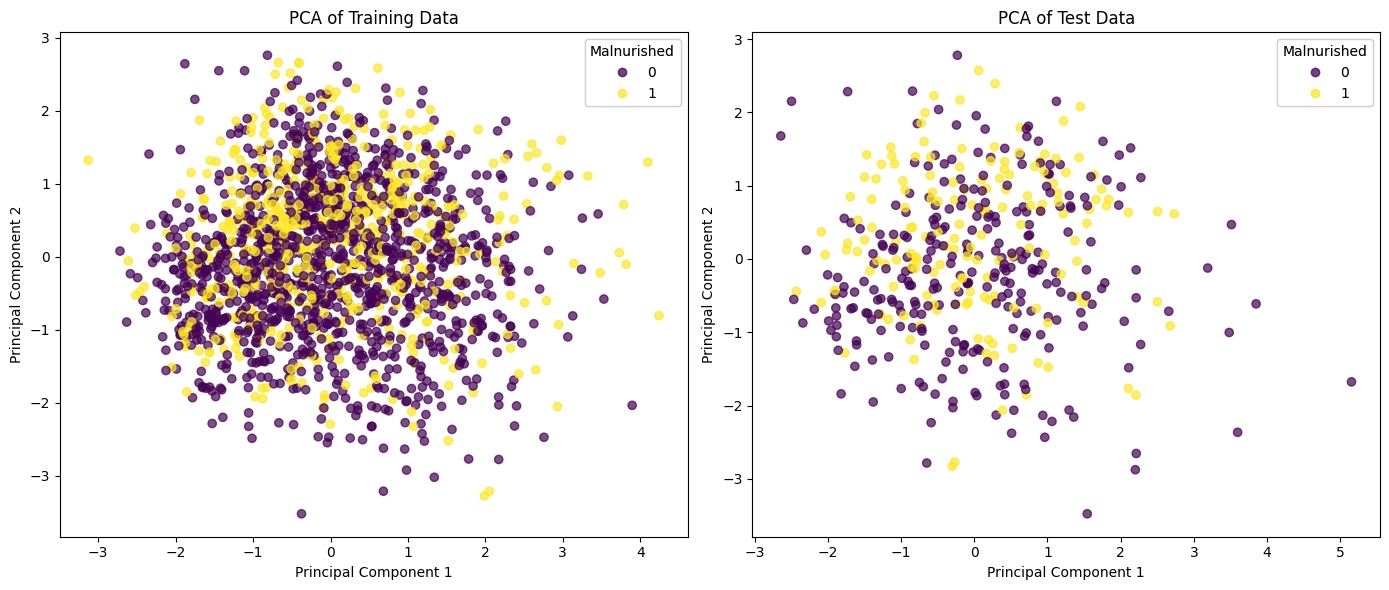

In [81]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

### Balancing using SMOTE

In [82]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1180, 1: 584})
After SMOTE:  Counter({0: 1180, 1: 1180})


**Cross-validation for Best k**

In [83]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sm, y_train_sm, cv = 5, scoring='recall')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

Best k after balancing: 3, Accuracy: 0.8924


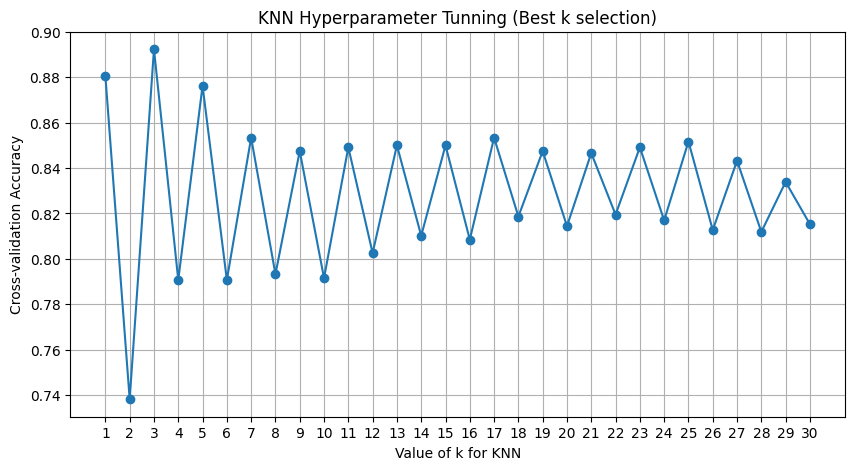

In [84]:
plt.figure(figsize=(10,5))
plt.plot(k_values, cv_scores, marker = 'o')
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-validation Accuracy')
plt.title('KNN Hyperparameter Tunning (Best k selection)')
plt.xticks(range(1,31,1))
plt.grid(True)
plt.show()

### Model Fit

In [85]:
knn_combined = KNeighborsClassifier(weights = 'distance', metric = 'manhattan', n_neighbors=5)
knn_combined.fit(X_train_sm, y_train_sm)
y_predict = knn_combined.predict(X_test_scaled)

print(accuracy_score(y_test, y_predict))
pd.crosstab(y_test, y_predict)

0.5260770975056689


col_0,0,1
Malnurished,,
0,152,128
1,81,80


#### Model's Performance

**Classification Report**

In [86]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.65      0.54      0.59       280
           1       0.38      0.50      0.43       161

    accuracy                           0.53       441
   macro avg       0.52      0.52      0.51       441
weighted avg       0.55      0.53      0.53       441



**ROC-AUC Score**

In [87]:
auc = roc_auc_score(y_test, knn_combined.predict_proba(X_test)[:,1])
print(f'ROC-AUC Score: {auc:.4f}')

ROC-AUC Score: 0.5539


**Average Precision**

In [88]:
average_precision_score(y_test, y_predict)

0.3747867039792505

Average Precision: 0.3980


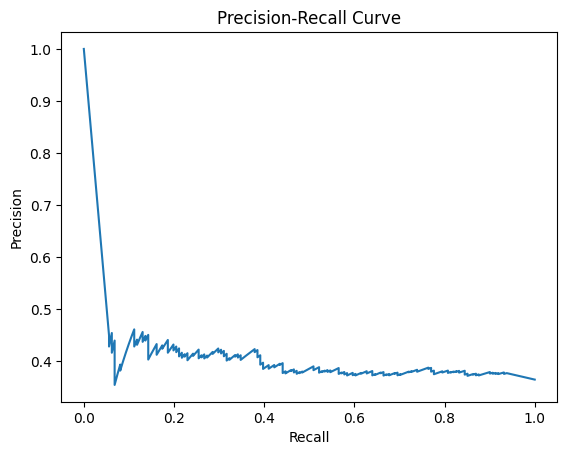

In [89]:
y_true = y_test  # True labels
y_scores = knn_combined.predict_proba(X_test_scaled)[:, 1]  # Probabilities for the positive class

# Get precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute Average Precision
ap = average_precision_score(y_true, y_scores)
print(f"Average Precision: {ap:.4f}")

# Plot Precision vs. Recall
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

ROC-AUC: 0.5381


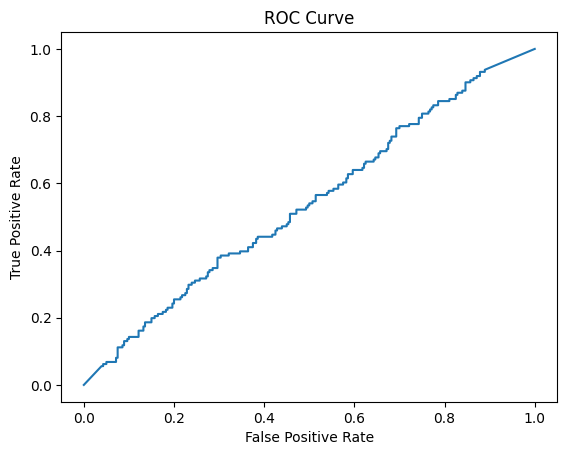

In [90]:
# Still using y_true and y_scores from above
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_true, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

# Plot ROC Curve
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

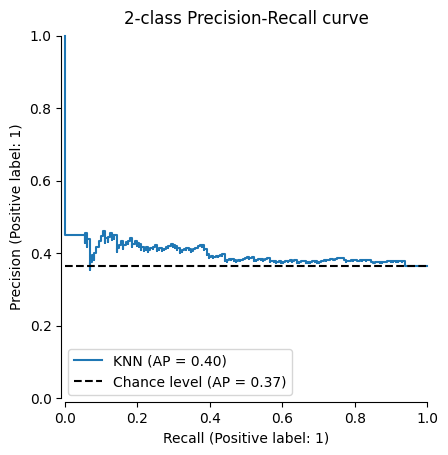

In [91]:
display = PrecisionRecallDisplay.from_estimator(
    knn_combined,         # trained model
    X_test_scaled,        # Test features
    y_test,               # True labels
    name="KNN",
    plot_chance_level=True,
    despine=True,
)

_ = display.ax_.set_title("2-class Precision-Recall curve")


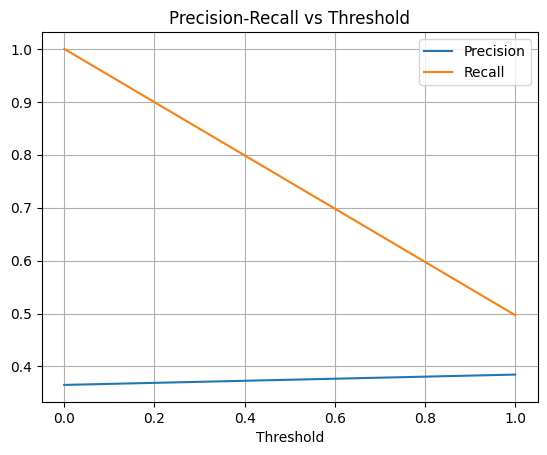

In [92]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_predict)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.show()

In [93]:
knn = KNeighborsClassifier(weights = 'distance', metric = 'manhattan', n_neighbors=5)
knn.fit(X_train_sm, y_train_sm)

y_predict = knn.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1

# Apply custom threshold
threshold = 0.30
y_pred_custom = (y_predict >= threshold).astype(int)
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.68      0.28      0.40       280
           1       0.38      0.78      0.51       161

    accuracy                           0.46       441
   macro avg       0.53      0.53      0.45       441
weighted avg       0.57      0.46      0.44       441



1. Feature Selection
2. Difference between Precision-Recall Curve and 2-Class Precision-Recall Curve